Import libraries

In [335]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold

Make (next series) random numbers predictable

In [336]:
np.random.seed(0)

Generate a sample of random numbers drawn from a normal (Gaussian) distribution

In [337]:
# dogs: higher ear flappiness index, lower whisker length
dogs_whisker_length = np.random.normal(loc=5, scale=1, size=10)
dogs_ear_flappiness_index = np.random.normal(loc=8, scale=1, size=10)

In [338]:
# cats: lower ear flappiness index, higher whisker length
cats_whisker_length = np.random.normal(loc=8, scale=1, size=10)
cats_ear_flappiness_index = np.random.normal(loc=5, scale=1, size=10)

In [339]:
# prepare data for algorithm
dogs_data = np.vstack((dogs_whisker_length, dogs_ear_flappiness_index)).T
cats_data = np.vstack((cats_whisker_length, cats_ear_flappiness_index)).T
data = np.vstack((dogs_data, cats_data))
lables = np.hstack((np.zeros(len(dogs_data)), np.ones(len(cats_data))))

In [340]:
print(">> dogs_data:\n", dogs_data)
print(">> cats_data:\n", cats_data)
print(">> data:\n", data)
print(">> lables:\n", lables)

>> dogs_data:
 [[6.76405235 8.14404357]
 [5.40015721 9.45427351]
 [5.97873798 8.76103773]
 [7.2408932  8.12167502]
 [6.86755799 8.44386323]
 [4.02272212 8.33367433]
 [5.95008842 9.49407907]
 [4.84864279 7.79484174]
 [4.89678115 8.3130677 ]
 [5.4105985  7.14590426]]
>> cats_data:
 [[ 5.44701018  5.15494743]
 [ 8.6536186   5.37816252]
 [ 8.8644362   4.11221425]
 [ 7.25783498  3.01920353]
 [10.26975462  4.65208785]
 [ 6.54563433  5.15634897]
 [ 8.04575852  6.23029068]
 [ 7.81281615  6.20237985]
 [ 9.53277921  4.61267318]
 [ 9.46935877  4.69769725]]
>> data:
 [[ 6.76405235  8.14404357]
 [ 5.40015721  9.45427351]
 [ 5.97873798  8.76103773]
 [ 7.2408932   8.12167502]
 [ 6.86755799  8.44386323]
 [ 4.02272212  8.33367433]
 [ 5.95008842  9.49407907]
 [ 4.84864279  7.79484174]
 [ 4.89678115  8.3130677 ]
 [ 5.4105985   7.14590426]
 [ 5.44701018  5.15494743]
 [ 8.6536186   5.37816252]
 [ 8.8644362   4.11221425]
 [ 7.25783498  3.01920353]
 [10.26975462  4.65208785]
 [ 6.54563433  5.15634897]
 [ 8.0

In [341]:
# split data into training and testing
x_train, x_test, y_train, y_test = train_test_split(data, lables, test_size=0.2, random_state=42)

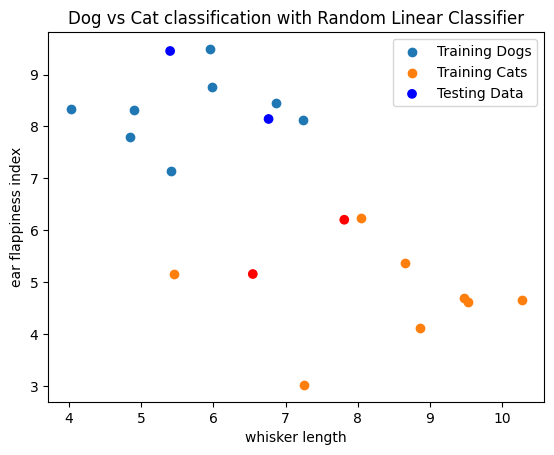

In [342]:
# plot the data points
plt.scatter(x_train[y_train == 0][:,0], x_train[y_train == 0][:,1], label="Training Dogs")
plt.scatter(x_train[y_train == 1][:,0], x_train[y_train == 1][:,1], label="Training Cats")
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap="bwr", label="Testing Data")
plt.xlabel("whisker length")
plt.ylabel("ear flappiness index")
plt.title("Dog vs Cat classification with Random Linear Classifier")
plt.legend()
plt.show()

In [343]:
print(">> x_train:\n", x_train)
print(">> x_test:\n", x_test)
print(">> y_train:\n", y_train)
print(">> y_test:\n", y_test)

>> x_train:
 [[ 4.89678115  8.3130677 ]
 [ 4.02272212  8.33367433]
 [ 8.6536186   5.37816252]
 [ 7.2408932   8.12167502]
 [ 9.53277921  4.61267318]
 [ 8.04575852  6.23029068]
 [ 7.25783498  3.01920353]
 [ 5.97873798  8.76103773]
 [ 5.4105985   7.14590426]
 [ 9.46935877  4.69769725]
 [ 6.86755799  8.44386323]
 [ 8.8644362   4.11221425]
 [ 4.84864279  7.79484174]
 [ 5.44701018  5.15494743]
 [10.26975462  4.65208785]
 [ 5.95008842  9.49407907]]
>> x_test:
 [[6.76405235 8.14404357]
 [7.81281615 6.20237985]
 [6.54563433 5.15634897]
 [5.40015721 9.45427351]]
>> y_train:
 [0. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0.]
>> y_test:
 [0. 1. 1. 0.]


In [344]:
# random linear classifier
def random_linear_classifier(data_dogs, data_cats, k, d):
  # d is the number of features
  best_error = float("inf")
  best_theta = None
  best_theta0 = None

  for _ in range(k):
    theta = np.random.normal(size=d)
    theta0 = np.random.normal()

    error = compute_error(data_dogs, data_cats, theta, theta0)

    if error < best_error:
      best_error = error
      best_theta = theta
      best_theta0 = theta0

  return best_theta, best_theta0, best_error

In [345]:
def compute_error(data_dogs, data_cats, theta, theta0):
  error = 0
  for x_dog in data_dogs:
    if np.dot(theta, x_dog) + theta0 <= 0:
      error += 1

  for x_cat in data_cats:
    if np.dot(theta, x_cat) + theta0 > 0:
      error += 1

  return error

In [346]:
# run algorithm
k = 100 # number of iterations
d = 2 # number of features
best_theta_train, best_theta0_train, train_error = random_linear_classifier(x_train[y_train == 0], x_train[y_train == 1], k, d)


In [347]:
print(">> best theta train: ", best_theta_train)
print(">> best theta0 train: ", best_theta0_train)

>> best theta train:  [-1.07075262  1.05445173]
>> best theta0 train:  -0.40317694697317963


In [348]:
# decision boundary for training data
x_vals_train = np.linspace(2, 10, 100)
y_vals_train = (-best_theta_train[0] / best_theta_train[1]) * x_vals_train - (best_theta0_train / best_theta_train[1])

In [349]:
print(">> x vals: ", x_vals_train)
print(">> y vals: ", y_vals_train)

>> x vals:  [ 2.          2.08080808  2.16161616  2.24242424  2.32323232  2.4040404
  2.48484848  2.56565657  2.64646465  2.72727273  2.80808081  2.88888889
  2.96969697  3.05050505  3.13131313  3.21212121  3.29292929  3.37373737
  3.45454545  3.53535354  3.61616162  3.6969697   3.77777778  3.85858586
  3.93939394  4.02020202  4.1010101   4.18181818  4.26262626  4.34343434
  4.42424242  4.50505051  4.58585859  4.66666667  4.74747475  4.82828283
  4.90909091  4.98989899  5.07070707  5.15151515  5.23232323  5.31313131
  5.39393939  5.47474747  5.55555556  5.63636364  5.71717172  5.7979798
  5.87878788  5.95959596  6.04040404  6.12121212  6.2020202   6.28282828
  6.36363636  6.44444444  6.52525253  6.60606061  6.68686869  6.76767677
  6.84848485  6.92929293  7.01010101  7.09090909  7.17171717  7.25252525
  7.33333333  7.41414141  7.49494949  7.57575758  7.65656566  7.73737374
  7.81818182  7.8989899   7.97979798  8.06060606  8.14141414  8.22222222
  8.3030303   8.38383838  8.46464646  8.5

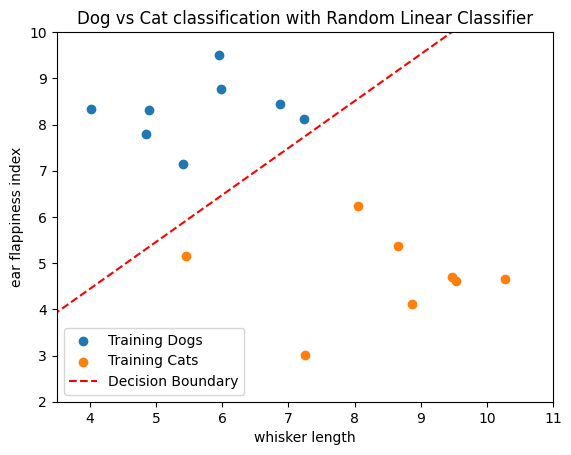

In [350]:
plt.scatter(x_train[y_train == 0][:,0], x_train[y_train == 0][:,1], label="Training Dogs")
plt.scatter(x_train[y_train == 1][:,0], x_train[y_train == 1][:,1], label="Training Cats")
plt.plot(x_vals_train, y_vals_train, color='red', linestyle='--', label="Decision Boundary")

# set same limits for x and y axis
plt.xlim([3.5, 11])
plt.ylim([2,10])
plt.xlabel("whisker length")
plt.ylabel("ear flappiness index")
plt.title("Dog vs Cat classification with Random Linear Classifier")
plt.legend()
plt.show()

In [351]:
print(">> training error: ", train_error)

>> training error:  0


In [352]:
# compute testing error
test_error = compute_error(x_test[y_test == 0], x_test[y_test == 1], best_theta_train, best_theta0_train)
print(">> testing error: ", test_error)

>> testing error:  0


Predicted labels: [1 0 0 1]


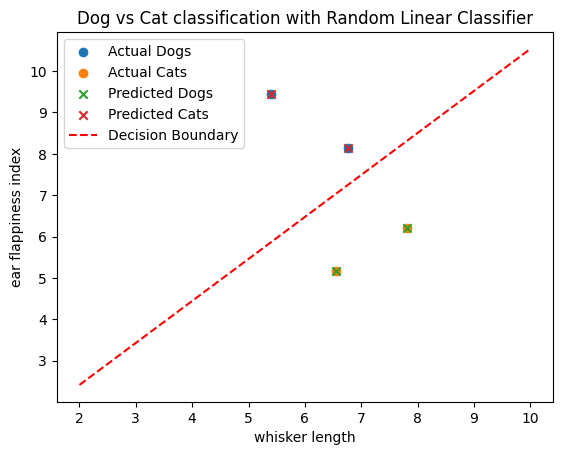

In [353]:
# plot the actual test data and predicted test data
plt.scatter(x_test[y_test == 0][:, 0], x_test[y_test == 0][:, 1], label="Actual Dogs")
plt.scatter(x_test[y_test == 1][:, 0], x_test[y_test == 1][:, 1], label="Actual Cats")

# predict test data points using the decision boundary
predicted_labels = np.zeros_like(y_test, dtype=int)
for i, x_t in enumerate(x_test):
  if np.dot(best_theta_train, x_t) + best_theta0_train > 0:
    predicted_labels[i] = 1

print(f"Predicted labels: {predicted_labels}")

# plot predicted test data points
plt.scatter(x_test[predicted_labels == 0][:, 0], x_test[predicted_labels == 0][:, 1], marker='x', label="Predicted Dogs")
plt.scatter(x_test[predicted_labels == 1][:, 0], x_test[predicted_labels == 1][:, 1], marker='x', label="Predicted Cats")

# plot decision boundary
plt.plot(x_vals_train, y_vals_train, color='red', linestyle='--', label="Decision Boundary")

plt.xlabel("whisker length")
plt.ylabel("ear flappiness index")
plt.title("Dog vs Cat classification with Random Linear Classifier")
plt.legend()
plt.show()